In [1]:
from tensorboard.backend.event_processing import event_accumulator

from pathlib import Path

from glob import glob

import pandas as pd 

from torch.utils.data import DataLoader

from matplotlib import pyplot as plt

from xaikd import models, datasets
from xaikd.utils import metrics

from xaikd.approximators import ApproximatorMode, normalize_mode_name

import numpy as np 

In [2]:
DATASET = "cifar100-people"

BASIS_DATA_DIR = Path(f"../../artifacts/2023-08-s10/experiments/distill-refactored-3-rng")


In [3]:
ACCURACY_CACHE = dict()

def get_accuracy(arch, dataset):
    
    
    key = f"{arch}-{dataset}"

    if key in ACCURACY_CACHE:
        return ACCURACY_CACHE[key]
    
    
    model = models.get_model(arch)
    ds = datasets.construct(dataset)
    
    ds_val = ds.create_subset(train_split=False)
    
    val_dl = DataLoader(ds_val, batch_size=128, shuffle=False)
    
    acc = metrics.accuracy_with_subclasses(
        model, 
        val_dl,
        ds.selected_classes,
        ds.transform_target,
        device="cpu"
    )
    
    ACCURACY_CACHE[key] = acc
    
    return get_accuracy(arch, dataset)
    
teacher_acc = get_accuracy("cifar100-resnet18-p1", DATASET)
teacher_acc

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


0.550000011920929

In [4]:
def get_basis_performance(layer, basis_name, compr_ratio, training_size, col, lambda_mse, lambda_xent, mode):
    
    nseeds = list(range(1, 5+1))
    rows = []

    for seed in nseeds:

        path = BASIS_DATA_DIR \
            / f"{DATASET}-tz{training_size}-seed{seed}" \
            / "cifar100-resnet18-p1" \
            / f"layer-{layer}" \
            / "distillation" \
            / f"{normalize_mode_name(mode)}-comp{compr_ratio}-wd0.0-ldmse{lambda_mse}-ldxent{lambda_xent}" \
            / basis_name \
            / "log/*/version_0/*.tfevents*"
        
        all_paths = list(glob(f"{path}"))
        try:
            assert len(all_paths) == 1, \
                f"we should have only one log file (but we have {len(all_paths)} files)\n> {path}"
        except:
            print(path)
            raise
        tfevent = all_paths[0]

        ea = event_accumulator.EventAccumulator(tfevent)

        ea.Reload()


        for r in ea.Scalars(col):
            rows.append(dict(step=r.step, col=r.value))
    df =  pd.DataFrame(rows)
    return df.groupby("step").agg({'step': ['max'], "col": ['mean', 'std', 'count']})
    
    
get_basis_performance(
    "layer3", basis_name="prca-recon--centered", compr_ratio=10.0,
    training_size=0.1, col="val_acc", lambda_mse=1.0, lambda_xent=0.0,
    mode=ApproximatorMode.HOMOGENOUS_LOWRANK
)

step     col                
      max    mean       std count
step                             
0       0  0.2064  0.029509     5
1       1  0.2324  0.019718     5
2       2  0.2668  0.018417     5
3       3  0.2764  0.015900     5
4       4  0.2860  0.030692     5
...   ...     ...       ...   ...
95     95  0.4408  0.020765     5
96     96  0.4436  0.021559     5
97     97  0.4488  0.024273     5
98     98  0.4424  0.021790     5
99     99  0.4512  0.019524     5

[100 rows x 4 columns]

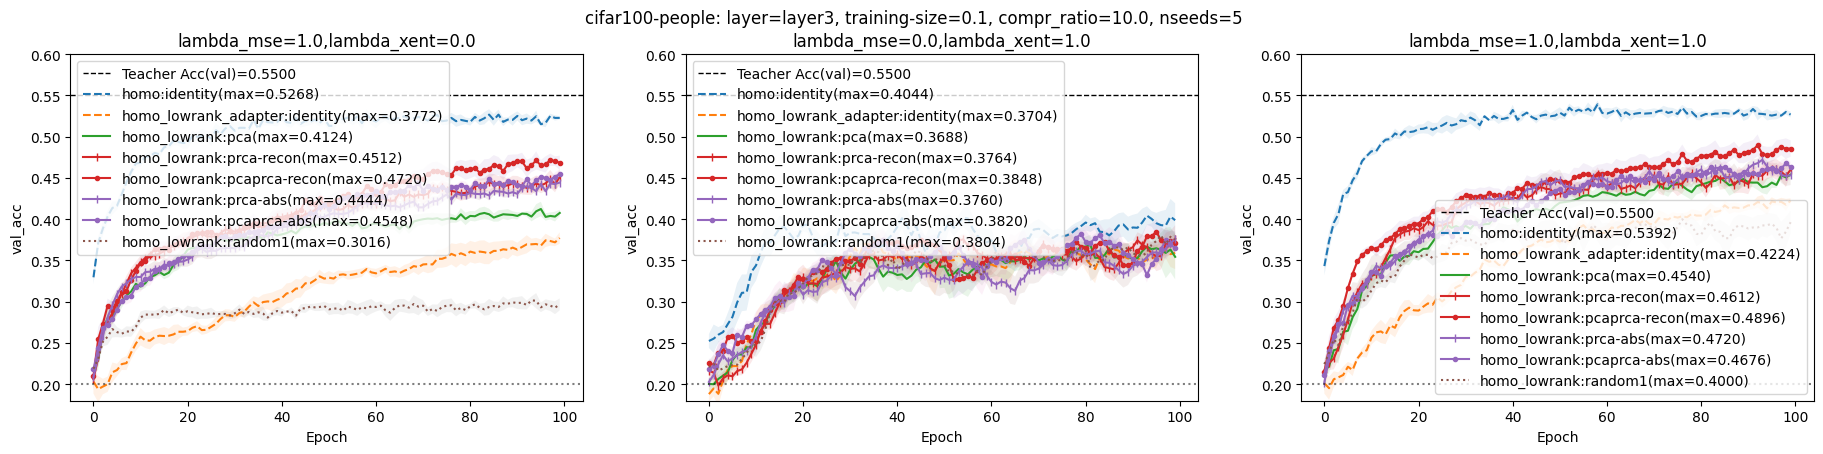

In [5]:
def marker(basis_name):
    if basis_name in ["prca-abs", "prca-recon"]:
        return "|"
    if "pcaprca" in basis_name:
        return "."
    else:
        return ""
    
def label(basis_name, approx_mode):
    short_approx_mode = normalize_mode_name(approx_mode).replace("genous", "")
    return f"{short_approx_mode}:{basis_name}"
    
def ls(basis_name):
    if basis_name == "identity":
        return "--"
    elif "random" in basis_name:
        return ":"
    else:
        return "-"

def viz(
    compr_ratio, col, training_size,
    arr_lambda_mse_xent_pairs = [
        (1.0, 1.0),
        (0.0, 1.0),
        (1.0, 0.0),
    ],
    basis_names = [
        "pca",
        "prca-recon",
        "pcaprca-recon",
        "prca-abs",
        "pcaprca-abs",
        "random1"
    ]
):
    layer = "layer3"
    nrows = 1 
    

    ncols = len(arr_lambda_mse_xent_pairs)
    
    plt.figure(figsize=(5*ncols*1.5, 3*nrows*1.5))
    
    
    arr_basis_confs = [
        (ApproximatorMode.HOMOGENOUS, "identity", "uncentered", 1.0),
        (ApproximatorMode.HOMOGENOUS_LOWRANK_ADAPTER, "identity", "uncentered", compr_ratio)
    ] + list(
        map(
            lambda name: (ApproximatorMode.HOMOGENOUS_LOWRANK, name, "centered", compr_ratio),
            basis_names
        )
    )
    
    
    for nix, (lambda_mse, lambda_xent) in enumerate(arr_lambda_mse_xent_pairs):
        plt.subplot(1, ncols, nix+1)
    

        plt.ylabel(col)
        plt.axhline(teacher_acc, label=f"Teacher Acc(val)={teacher_acc:.4f}", ls="--", lw=1, color='k')

        for approx_mode, basis_name, basis_mode, compr_ratio in arr_basis_confs:
            df = get_basis_performance(
                layer,
                basis_name=f"{basis_name}--{basis_mode}",
                compr_ratio=compr_ratio,
                training_size=training_size,
                col=col,
                lambda_mse=lambda_mse,
                lambda_xent=lambda_xent,
                mode=approx_mode
            )

            mean = df.col[["mean"]].values.reshape(-1)
            nseeds = df.col[["count"]].values.reshape(-1)[0]
            stderr = df.col[["std"]].values.reshape(-1) / (nseeds**0.5)
            
            steps = df.step[["max"]].values.reshape(-1)
            steps = np.arange(steps.shape[0])

            
            if "pcaprca" in basis_name:
                color = plt.gca().lines[-1].get_color()
            else:
                color=None

            plt.plot(
                steps,
                mean,
                label=f"{label(basis_name, approx_mode)}(max={mean.max():.4f})",
                ls=ls(basis_name),
                marker=marker(basis_name),
                color=color
            )
            
            plt.fill_between(
                steps,
                mean - stderr,
                mean + stderr,
                alpha=0.1
            )

        plt.title(f"lambda_mse={lambda_mse},lambda_xent={lambda_xent}")

        plt.legend()

        plt.xlabel("Epoch")
        plt.ylim([0.18, teacher_acc+0.05])
        plt.axhline(0.20, ls=":", alpha=0.5, color="k")
        
    plt.suptitle(f"{DATASET}: layer={layer}, training-size={training_size}, compr_ratio={compr_ratio}, nseeds={nseeds}")  
    

viz(
    training_size=0.1,
    compr_ratio=10.0,
    col="val_acc",
    arr_lambda_mse_xent_pairs=[
        (1.0, 0.0), 
        (0.0, 1.0), 
        (1.0, 1.0)
    ],
)

In [ ]:
viz(
    training_size=1.0,
    compr_ratio=10.0,
    col="val_acc",
    arr_lambda_mse_xent_pairs=[
        (1.0, 0.0), 
        (0.0, 1.0), 
        (1.0, 1.0)
    ],
)